# Linear Regression Task — Student Habits vs Academic Performance

**Mission:** Investigate how student wellbeing (sleep, mental health, exercise, diet) and study habits relate to academic performance, in order to help identify students who may need support.

**Dataset:** Student Habits vs Academic Performance (Kaggle) — 1000 students, 16 columns, target = `exam_score`.

## 1. Load and Inspect Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('student_habits_performance.csv')
print(df.shape)
df.head()

(1000, 16)


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [2]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   str    
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   str    
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   str    
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   str    
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    str    
 12  internet_quality               1000 non-null   str    
 13  

student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

## 2. Exploratory Data Analysis (EDA)

### 2.1 Correlation Heatmap

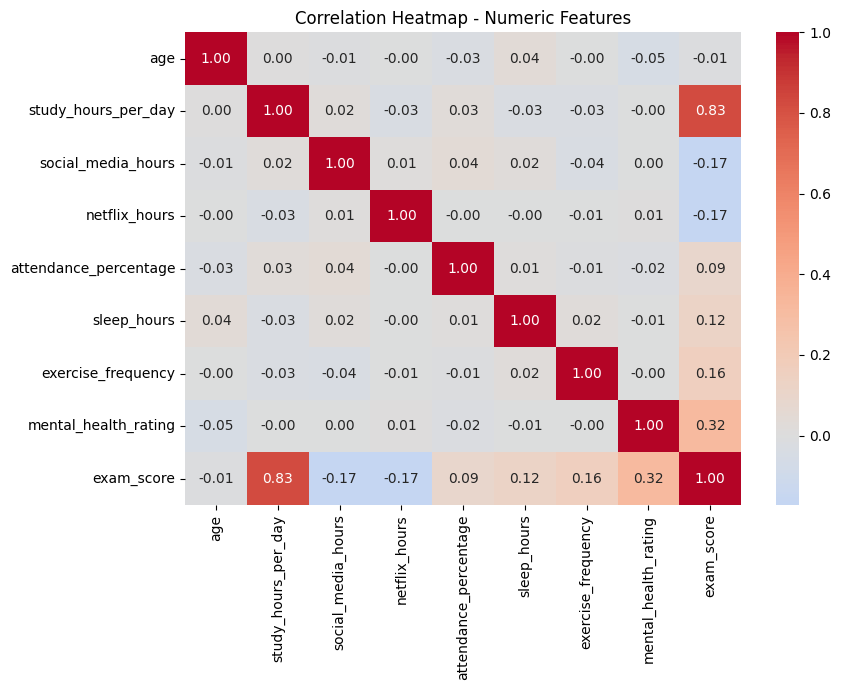

In [3]:
df_numeric = df.select_dtypes(include='number')
plt.figure(figsize=(9,7))
sns.heatmap(df_numeric.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap - Numeric Features')
plt.tight_layout()
plt.show()

**Interpretation:** `study_hours_per_day` shows the strongest correlation with `exam_score` (~0.83), followed by `mental_health_rating` (~0.32). `social_media_hours` and `netflix_hours` show weak negative correlations (~-0.17). `age` shows almost no relationship (~-0.01) and is a candidate for dropping.

### 2.2 Distribution of Numeric Features

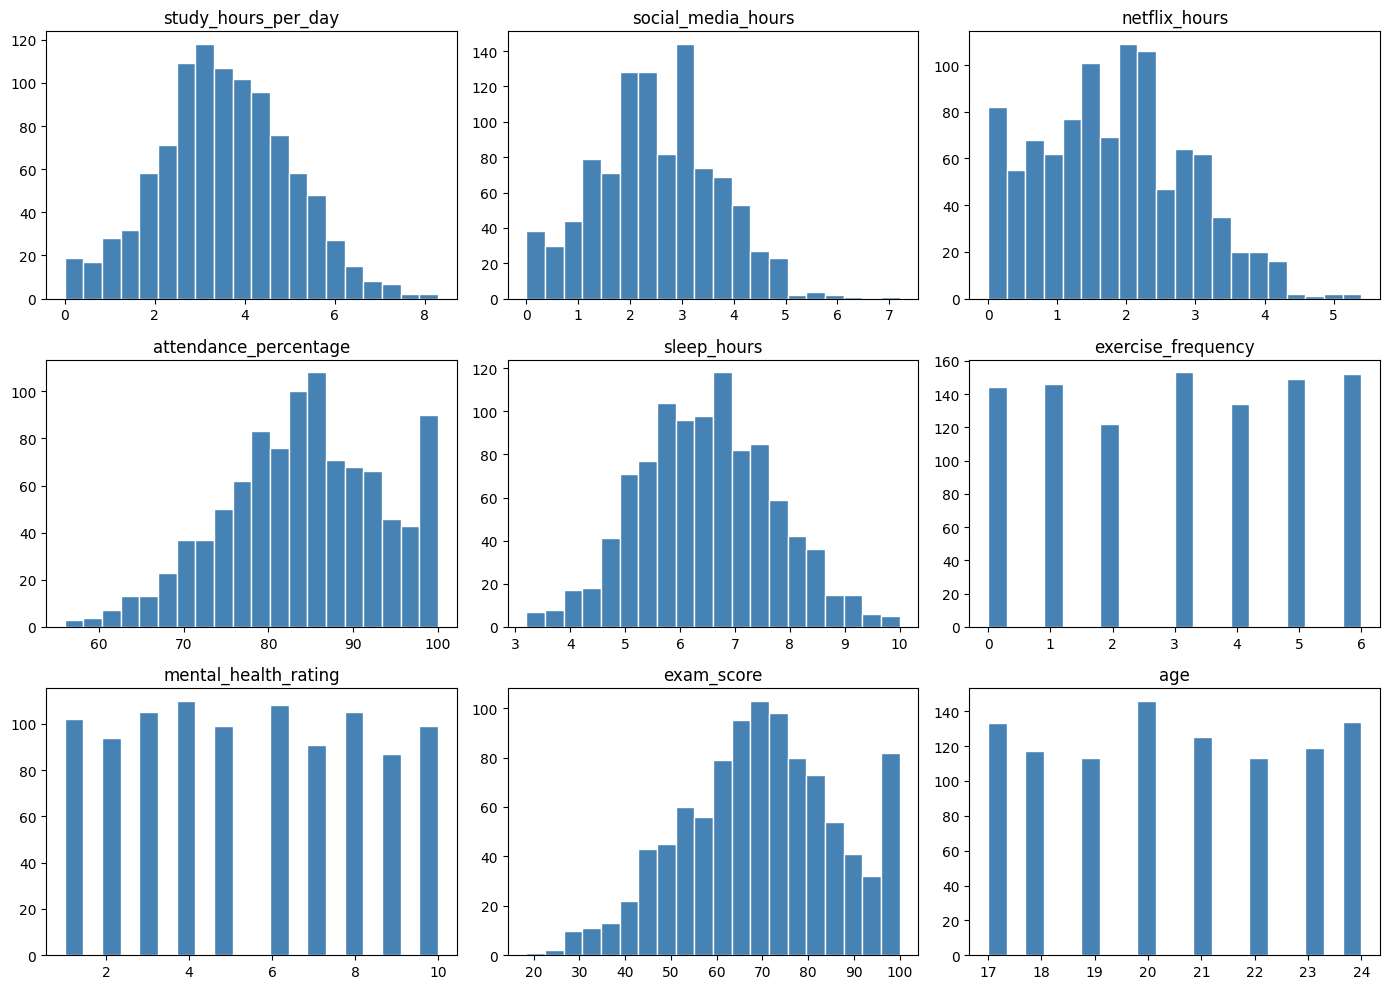

Skew:
study_hours_per_day      0.054253
social_media_hours       0.119805
netflix_hours            0.237154
attendance_percentage   -0.237810
sleep_hours              0.091484
exercise_frequency      -0.031923
mental_health_rating     0.037811
exam_score              -0.156351
age                      0.008437
dtype: float64


In [4]:
numeric_cols = ['study_hours_per_day', 'social_media_hours', 'netflix_hours',
                'attendance_percentage', 'sleep_hours', 'exercise_frequency',
                'mental_health_rating', 'exam_score', 'age']
fig, axes = plt.subplots(3, 3, figsize=(14,10))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

print('Skew:')
print(df[numeric_cols].skew())

**Interpretation:** All numeric features have skew close to 0 (roughly -0.24 to 0.24), meaning distributions are fairly symmetric with no heavy outlier tails. No transformation (e.g. log) is needed.

### 2.3 Categorical Features vs Exam Score (Boxplots)

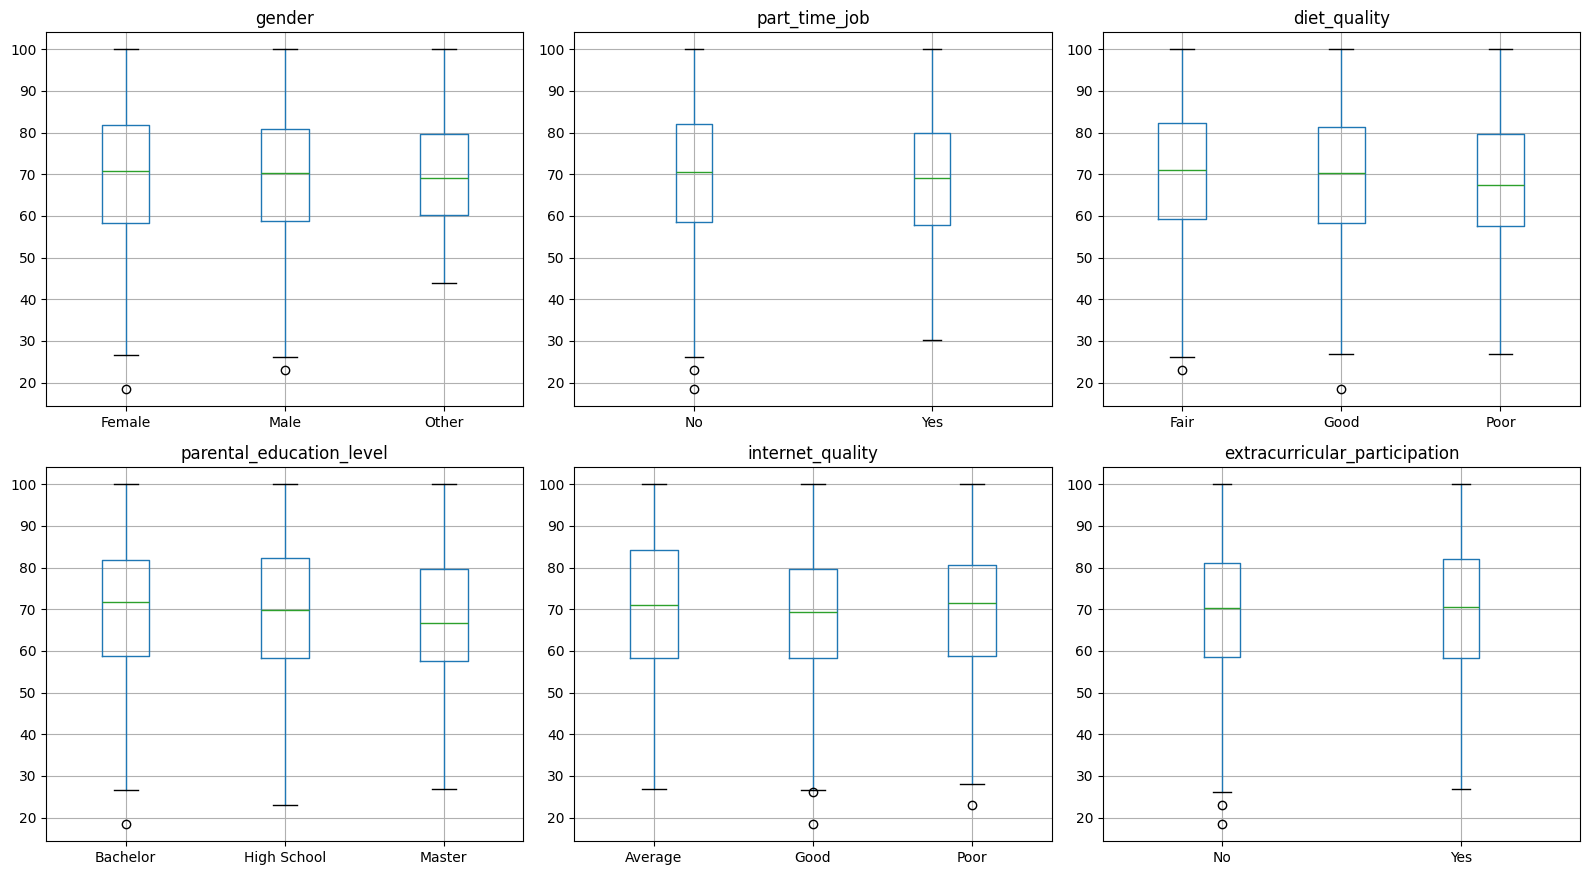

In [5]:
cat_cols = ['gender', 'part_time_job', 'diet_quality', 'parental_education_level',
            'internet_quality', 'extracurricular_participation']
fig, axes = plt.subplots(2, 3, figsize=(16,9))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    df.boxplot(column='exam_score', by=col, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
plt.suptitle('')
plt.tight_layout()
plt.show()

**Interpretation:** Categorical features show heavily overlapping boxes with similar medians (all roughly 67-72), indicating weak individual predictive power compared to numeric features like `study_hours_per_day`. They are kept in the model since small combined effects can still help.

## 3. Feature Engineering

In [6]:
# Drop unhelpful columns
df = df.drop(columns=['student_id', 'age'])

# Fill missing categorical values
df['parental_education_level'] = df['parental_education_level'].fillna('Unknown')

# Label encode ordered categories
diet_order = {'Poor': 0, 'Fair': 1, 'Good': 2}
df['diet_quality'] = df['diet_quality'].map(diet_order)

internet_order = {'Poor': 0, 'Average': 1, 'Good': 2}
df['internet_quality'] = df['internet_quality'].map(internet_order)

# One-hot encode unordered categories
onehot_cols = ['gender', 'part_time_job', 'extracurricular_participation', 'parental_education_level']
df = pd.get_dummies(df, columns=onehot_cols, drop_first=True)

print(df.shape)
df.head()

(1000, 17)


,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,internet_quality,mental_health_rating,exam_score,gender_Male,gender_Other,part_time_job_Yes,extracurricular_participation_Yes,parental_education_level_High School,parental_education_level_Master,parental_education_level_Unknown
0,0.0,1.2,1.1,85.0,8.0,1,6,1,8,56.2,False,False,False,True,False,True,False
1,6.9,2.8,2.3,97.3,4.6,2,6,1,8,100.0,False,False,False,False,True,False,False
2,1.4,3.1,1.3,94.8,8.0,0,1,0,1,34.3,True,False,False,False,True,False,False
3,1.0,3.9,1.0,71.0,9.2,0,4,2,1,26.8,False,False,False,True,False,True,False
4,5.0,4.4,0.5,90.9,4.9,1,3,2,1,66.4,False,False,False,False,False,True,False


## 4. Train/Test Split and Standardization

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['exam_score'])
y = df['exam_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Train shape:', X_train_scaled.shape, ' Test shape:', X_test_scaled.shape)

Train shape: (800, 16)  Test shape: (200, 16)


## 5. Model Training and Comparison

We compare Linear Regression (trained with Gradient Descent via `SGDRegressor`) against Random Forest and Decision Tree regressors.

In [8]:
from sklearn.linear_model import SGDRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

results = {}

# Linear Regression via Gradient Descent
sgd = SGDRegressor(max_iter=1000, tol=1e-3, random_state=42)
sgd.fit(X_train_scaled, y_train)
pred_sgd = sgd.predict(X_test_scaled)
results['Linear Regression (Gradient Descent)'] = {
    'MSE': mean_squared_error(y_test, pred_sgd), 'R2': r2_score(y_test, pred_sgd)}

# Random Forest
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train_scaled, y_train)
pred_rf = rf.predict(X_test_scaled)
results['Random Forest'] = {
    'MSE': mean_squared_error(y_test, pred_rf), 'R2': r2_score(y_test, pred_rf)}

# Decision Tree
dt = DecisionTreeRegressor(max_depth=6, random_state=42)
dt.fit(X_train_scaled, y_train)
pred_dt = dt.predict(X_test_scaled)
results['Decision Tree'] = {
    'MSE': mean_squared_error(y_test, pred_dt), 'R2': r2_score(y_test, pred_dt)}

results_df = pd.DataFrame(results).T
results_df

,MSE,R2
Linear Regression (Gradient Descent),26.137944,0.898070
Random Forest,37.777199,0.852680
Decision Tree,85.663692,0.665936


**Interpretation:** Linear Regression (Gradient Descent) achieves the lowest MSE and highest R², which makes sense given the strongly linear relationship between `study_hours_per_day` and `exam_score` found during EDA. It is selected as the best-performing model.

## 6. Loss Curve (Train vs Test)

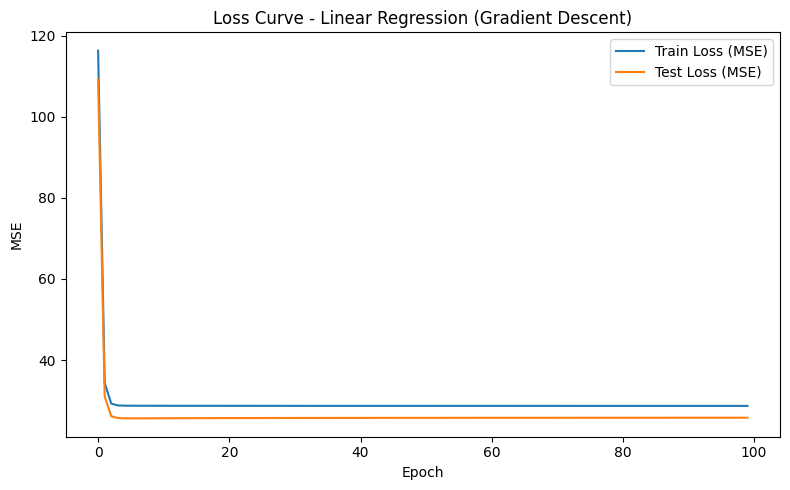

In [9]:
model_lc = SGDRegressor(max_iter=1, warm_start=True, learning_rate='invscaling', eta0=0.01, random_state=42)
train_losses, test_losses = [], []
epochs = 100

for epoch in range(epochs):
    model_lc.partial_fit(X_train_scaled, y_train)
    train_losses.append(mean_squared_error(y_train, model_lc.predict(X_train_scaled)))
    test_losses.append(mean_squared_error(y_test, model_lc.predict(X_test_scaled)))

plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss (MSE)')
plt.plot(test_losses, label='Test Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Loss Curve - Linear Regression (Gradient Descent)')
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation:** Train and test loss both decrease and converge closely together, indicating the model is not overfitting.

## 7. Scatter Plot: Fitted Line (Study Hours vs Exam Score)

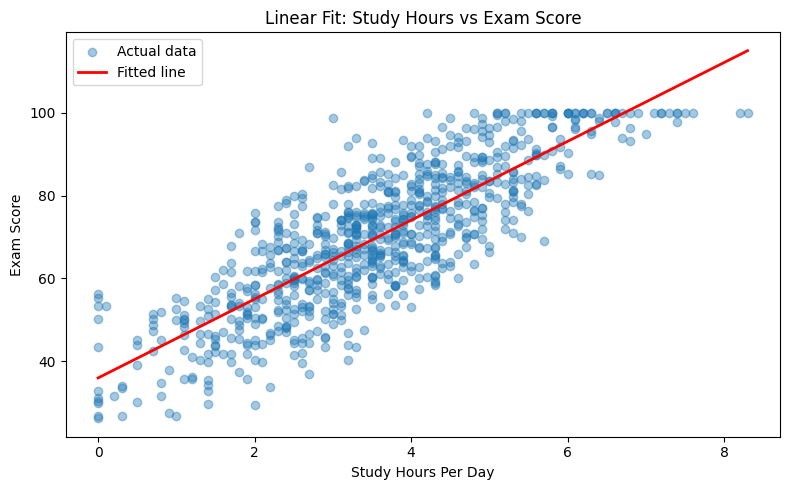

In [10]:
from sklearn.linear_model import LinearRegression

simple_model = LinearRegression()
simple_model.fit(X_train[['study_hours_per_day']], y_train)

plt.figure(figsize=(8,5))
plt.scatter(X_train['study_hours_per_day'], y_train, alpha=0.4, label='Actual data')
x_range = np.linspace(X_train['study_hours_per_day'].min(), X_train['study_hours_per_day'].max(), 100).reshape(-1,1)
x_range_df = pd.DataFrame(x_range, columns=['study_hours_per_day'])
plt.plot(x_range, simple_model.predict(x_range_df), color='red', linewidth=2, label='Fitted line')
plt.xlabel('Study Hours Per Day')
plt.ylabel('Exam Score')
plt.title('Linear Fit: Study Hours vs Exam Score')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Save Best Model

In [11]:
import joblib
import json

joblib.dump(sgd, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

with open('feature_order.json', 'w') as f:
    json.dump(list(X.columns), f)

print('Best model, scaler, and feature order saved.')

Best model, scaler, and feature order saved.


## 9. Make a Prediction on a Test Row (used in Task 2 API)

In [12]:
sample_row = X_test.iloc[[0]]
sample_scaled = scaler.transform(sample_row)
prediction = sgd.predict(sample_scaled)

print('Sample input:')
print(sample_row)
print()
print('Predicted exam score:', prediction[0])
print('Actual exam score:', y_test.iloc[0])

Sample input:
     study_hours_per_day  social_media_hours  netflix_hours  \
521                  3.5                 2.1            1.4   

     attendance_percentage  sleep_hours  diet_quality  exercise_frequency  \
521                   82.2          7.7             1                   1   

     internet_quality  mental_health_rating  gender_Male  gender_Other  \
521                 2                     3         True         False   

     part_time_job_Yes  extracurricular_participation_Yes  \
521              False                              False   

     parental_education_level_High School  parental_education_level_Master  \
521                                  True                            False   

     parental_education_level_Unknown  
521                             False  

Predicted exam score: 65.83045543837088
Actual exam score: 64.2
